In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [1]:
iz = 244
bs = 32

In [6]:
training_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "train",
    shuffle = True,
    seed = 16,
    image_size = (iz, iz),
    batch_size = bs
)

Found 7222 files belonging to 4 classes.


In [4]:
for images, labels in training_ds.take(1):
    print(images.shape, labels.shape)
    print(images.dtype, labels.dtype)

(32, 244, 244, 3) (32,)
<dtype: 'float32'> <dtype: 'int32'>


In [5]:
amount = int(len(training_ds) * 20/100)
# amount
validation_ds = training_ds.take(amount)

In [3]:
testing_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "test",
    shuffle = True,
    seed = 16,
    image_size = (iz, iz),
    batch_size = bs
)

Found 1805 files belonging to 4 classes.


In [7]:
class_names = training_ds.class_names
class_names

class_number = len(class_names)
class_number

4

In [8]:
from tensorflow.keras.applications import ResNet50

model = models.Sequential()
model.add(ResNet50(include_top=False, pooling='max', weights='imagenet', input_shape = (iz, iz, 3)))
model.add(Dense(class_number, activation='softmax'))
model.layers[0].trainable = False

In [9]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 2048)              23587712  
                                                                 
 dense (Dense)               (None, 4)                 8196      
                                                                 
Total params: 23,595,908
Trainable params: 8,196
Non-trainable params: 23,587,712
_________________________________________________________________


In [10]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [11]:
early = EarlyStopping(monitor = 'val_loss', patience=3)

In [12]:
history_1 = model.fit(training_ds, epochs=10, validation_data=validation_ds, callbacks=early)

Epoch 1/10


226/226 [==============================] - 42s 111ms/step - loss: 0.4846 - accuracy: 0.8975 - val_loss: 0.2048 - val_accuracy: 0.9458
Epoch 2/10
226/226 [==============================] - 22s 98ms/step - loss: 0.0992 - accuracy: 0.9686 - val_loss: 0.0355 - val_accuracy: 0.9861
Epoch 3/10
226/226 [==============================] - 22s 99ms/step - loss: 0.0681 - accuracy: 0.9801 - val_loss: 0.0269 - val_accuracy: 0.9903
Epoch 4/10
226/226 [==============================] - 23s 99ms/step - loss: 0.0266 - accuracy: 0.9906 - val_loss: 0.0200 - val_accuracy: 0.9924
Epoch 5/10
226/226 [==============================] - 22s 99ms/step - loss: 0.0113 - accuracy: 0.9967 - val_loss: 0.0219 - val_accuracy: 0.9896
Epoch 6/10
226/226 [==============================] - 23s 99ms/step - loss: 0.0070 - accuracy: 0.9972 - val_loss: 0.0054 - val_accuracy: 0.9979
Epoch 7/10
226/226 [==============================] - 22s 98ms/step - loss: 0.0104 - accuracy: 0.9953 - val_loss: 0.0094 - val_accuracy: 0.9951
Ep

In [13]:
scores_1 = model.evaluate(testing_ds)
scores_1

57/57 [==============================] - 5s 82ms/step - loss: 0.0340 - accuracy: 0.9906


[0.03399067744612694, 0.9905816912651062]

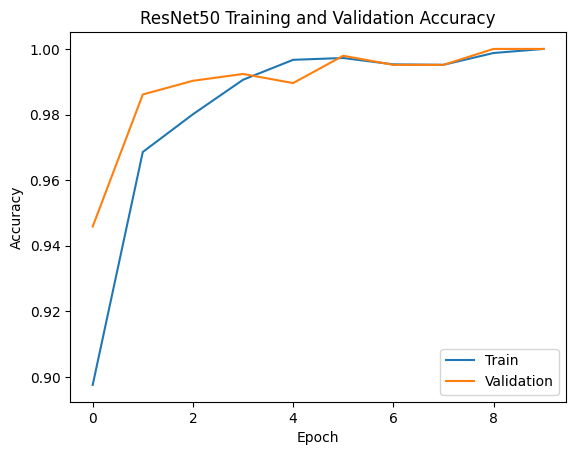

In [14]:
# Plot training and validation accuracy
plt.plot(history_1.history['accuracy'], label='Train')
plt.plot(history_1.history['val_accuracy'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('ResNet50 Training and Validation Accuracy')
plt.show()

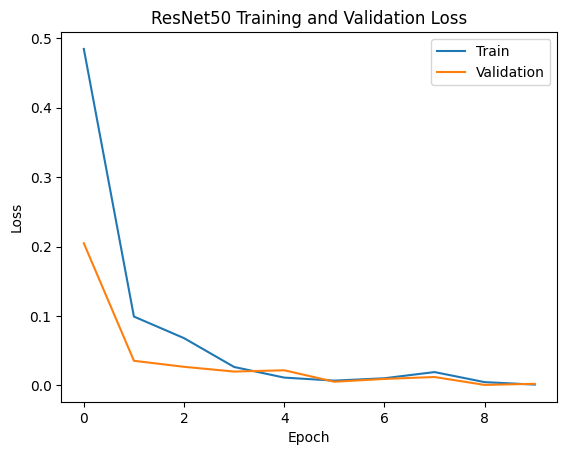

In [15]:
# Plot training and validation accuracy
plt.plot(history_1.history['loss'], label='Train')
plt.plot(history_1.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('ResNet50 Training and Validation Loss')
plt.show()

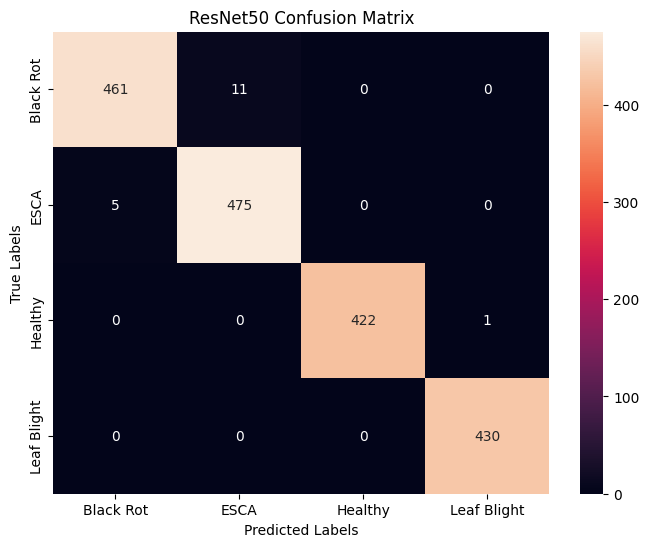

In [16]:
# Get the predicted labels for the test set
predicted_labels = []
true_labels = []

for images, labels in testing_ds:
    true_labels.extend(labels.numpy())
    predictions = model.predict(images, verbose=0)
    predicted_labels.extend(np.argmax(predictions, axis=1))

# Create a confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('ResNet50 Confusion Matrix')
plt.show()


In [17]:
model.save(f"../Models/ResNet50_V2")

INFO:tensorflow:Assets written to: ../Models/ResNet50_V2\assets


INFO:tensorflow:Assets written to: ../Models/ResNet50_V2\assets


In [18]:
from tensorflow.keras.applications import VGG16

model = models.Sequential()
model.add(VGG16(include_top=False, pooling='max', weights='imagenet', input_shape = (iz, iz, 3)))
model.add(Dense(class_number, activation='softmax'))
model.layers[0].trainable = False

In [19]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 512)               14714688  
                                                                 
 dense_1 (Dense)             (None, 4)                 2052      
                                                                 
Total params: 14,716,740
Trainable params: 2,052
Non-trainable params: 14,714,688
_________________________________________________________________


In [20]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [21]:
early = EarlyStopping(monitor = 'val_loss', patience=3)

In [22]:
history_2 = model.fit(training_ds, epochs=10, validation_data=validation_ds, callbacks=early)

Epoch 1/10


226/226 [==============================] - 41s 160ms/step - loss: 4.9423 - accuracy: 0.7530 - val_loss: 0.8986 - val_accuracy: 0.9118
Epoch 2/10
226/226 [==============================] - 33s 145ms/step - loss: 0.7959 - accuracy: 0.9320 - val_loss: 0.5575 - val_accuracy: 0.9361
Epoch 3/10
226/226 [==============================] - 33s 144ms/step - loss: 0.4969 - accuracy: 0.9538 - val_loss: 0.2731 - val_accuracy: 0.9694
Epoch 4/10
226/226 [==============================] - 49s 218ms/step - loss: 0.3481 - accuracy: 0.9626 - val_loss: 0.4347 - val_accuracy: 0.9493
Epoch 5/10
226/226 [==============================] - 33s 146ms/step - loss: 0.2715 - accuracy: 0.9705 - val_loss: 0.1543 - val_accuracy: 0.9778
Epoch 6/10
226/226 [==============================] - 49s 216ms/step - loss: 0.1793 - accuracy: 0.9748 - val_loss: 0.2574 - val_accuracy: 0.9694
Epoch 7/10
226/226 [==============================] - 33s 146ms/step - loss: 0.1310 - accuracy: 0.9785 - val_loss: 0.1572 - val_accuracy: 0.9

In [23]:
scores_2 = model.evaluate(testing_ds)
scores_2

57/57 [==============================] - 9s 161ms/step - loss: 0.5286 - accuracy: 0.9485


[0.5286381244659424, 0.9484764337539673]

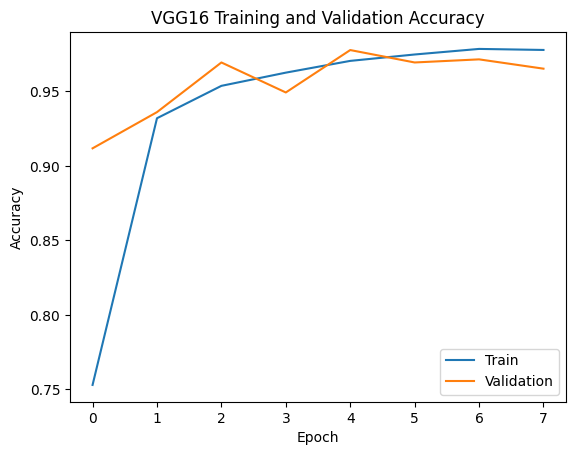

In [24]:
# Plot training and validation accuracy
plt.plot(history_2.history['accuracy'], label='Train')
plt.plot(history_2.history['val_accuracy'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('VGG16 Training and Validation Accuracy')
plt.show()

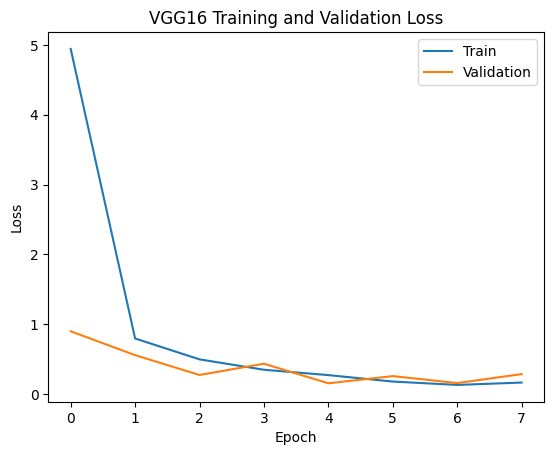

In [25]:
# Plot training and validation accuracy
plt.plot(history_2.history['loss'], label='Train')
plt.plot(history_2.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('VGG16 Training and Validation Loss')
plt.show()

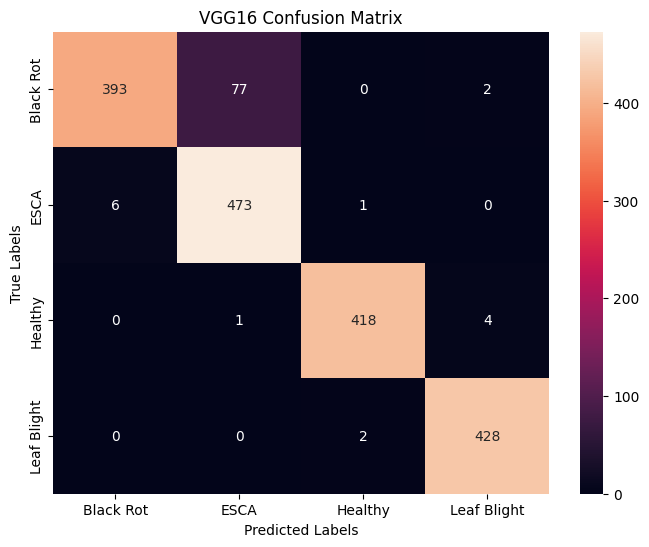

In [26]:
# Get the predicted labels for the test set
predicted_labels = []
true_labels = []

for images, labels in testing_ds:
    true_labels.extend(labels.numpy())
    predictions = model.predict(images, verbose=0)
    predicted_labels.extend(np.argmax(predictions, axis=1))

# Create a confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('VGG16 Confusion Matrix')
plt.show()


In [27]:
model.save(f"../Models/VGG16_V2")

INFO:tensorflow:Assets written to: ../Models/VGG16_V2\assets


INFO:tensorflow:Assets written to: ../Models/VGG16_V2\assets


In [28]:
from tensorflow.keras.applications import EfficientNetV2B3

model = models.Sequential()
model.add(EfficientNetV2B3(include_top=False, pooling='max', weights='imagenet', input_shape = (iz, iz, 3)))
model.add(Dense(class_number, activation='softmax'))
model.layers[0].trainable = False

In [29]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetv2-b3 (Function  (None, 1536)             12930622  
 al)                                                             
                                                                 
 dense_2 (Dense)             (None, 4)                 6148      
                                                                 
Total params: 12,936,770
Trainable params: 6,148
Non-trainable params: 12,930,622
_________________________________________________________________


In [30]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [31]:
early = EarlyStopping(monitor = 'val_loss', patience=3)

In [32]:
history_3 = model.fit(training_ds, epochs=10, validation_data=validation_ds, callbacks=early)

Epoch 1/10


226/226 [==============================] - 38s 121ms/step - loss: 0.5190 - accuracy: 0.8250 - val_loss: 0.1061 - val_accuracy: 0.9611
Epoch 2/10
226/226 [==============================] - 24s 106ms/step - loss: 0.1429 - accuracy: 0.9482 - val_loss: 0.0548 - val_accuracy: 0.9812
Epoch 3/10
226/226 [==============================] - 42s 185ms/step - loss: 0.0854 - accuracy: 0.9712 - val_loss: 0.0394 - val_accuracy: 0.9882
Epoch 4/10
226/226 [==============================] - 25s 108ms/step - loss: 0.0701 - accuracy: 0.9744 - val_loss: 0.0366 - val_accuracy: 0.9889
Epoch 5/10
226/226 [==============================] - 34s 151ms/step - loss: 0.0682 - accuracy: 0.9765 - val_loss: 0.0232 - val_accuracy: 0.9917
Epoch 6/10
226/226 [==============================] - 24s 107ms/step - loss: 0.0556 - accuracy: 0.9813 - val_loss: 0.0187 - val_accuracy: 0.9944
Epoch 7/10
226/226 [==============================] - 25s 109ms/step - loss: 0.0430 - accuracy: 0.9857 - val_loss: 0.0195 - val_accuracy: 0.9

In [33]:
scores_3 = model.evaluate(testing_ds)
scores_3

57/57 [==============================] - 6s 89ms/step - loss: 0.0527 - accuracy: 0.9823


[0.05265127494931221, 0.9822714924812317]

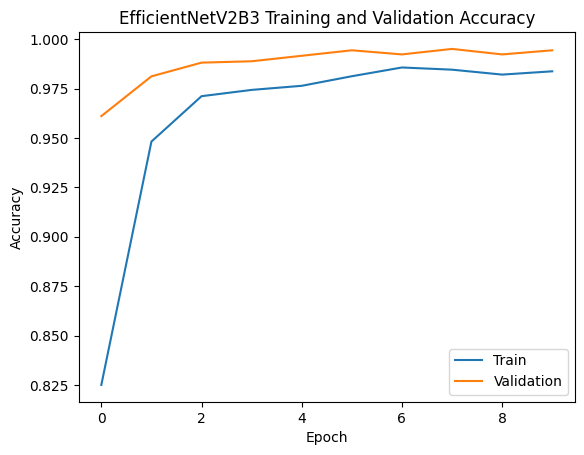

In [34]:
# Plot training and validation accuracy
plt.plot(history_3.history['accuracy'], label='Train')
plt.plot(history_3.history['val_accuracy'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('EfficientNetV2B3 Training and Validation Accuracy')
plt.show()

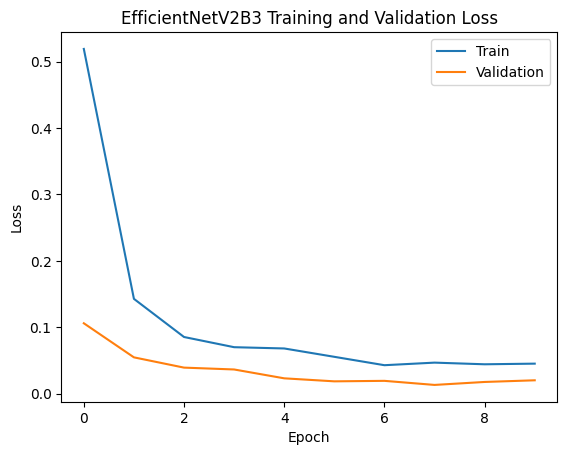

In [35]:
# Plot training and validation accuracy
plt.plot(history_3.history['loss'], label='Train')
plt.plot(history_3.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('EfficientNetV2B3 Training and Validation Loss')
plt.show()

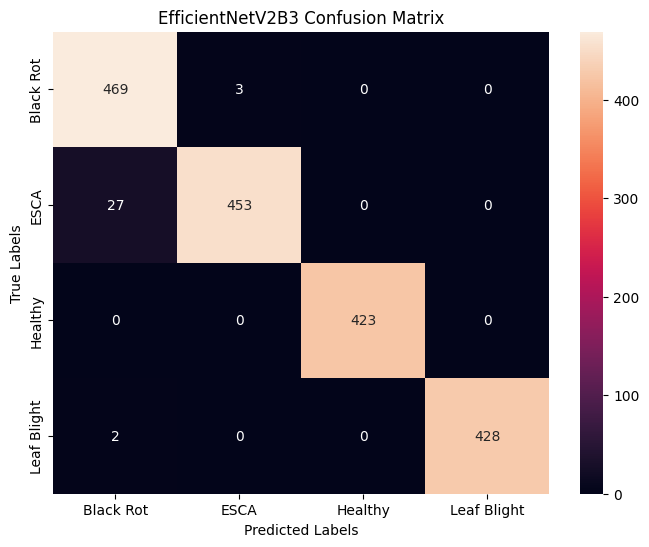

In [36]:
# Get the predicted labels for the test set
predicted_labels = []
true_labels = []

for images, labels in testing_ds:
    true_labels.extend(labels.numpy())
    predictions = model.predict(images, verbose=0)
    predicted_labels.extend(np.argmax(predictions, axis=1))

# Create a confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('EfficientNetV2B3 Confusion Matrix')
plt.show()

In [37]:
model.save(f"../Models/EfficientNetV2B3_V2")

INFO:tensorflow:Assets written to: ../Models/EfficientNetV2B3_V2\assets


INFO:tensorflow:Assets written to: ../Models/EfficientNetV2B3_V2\assets


In [5]:
model = models.load_model(f"../Models/ResNet50")

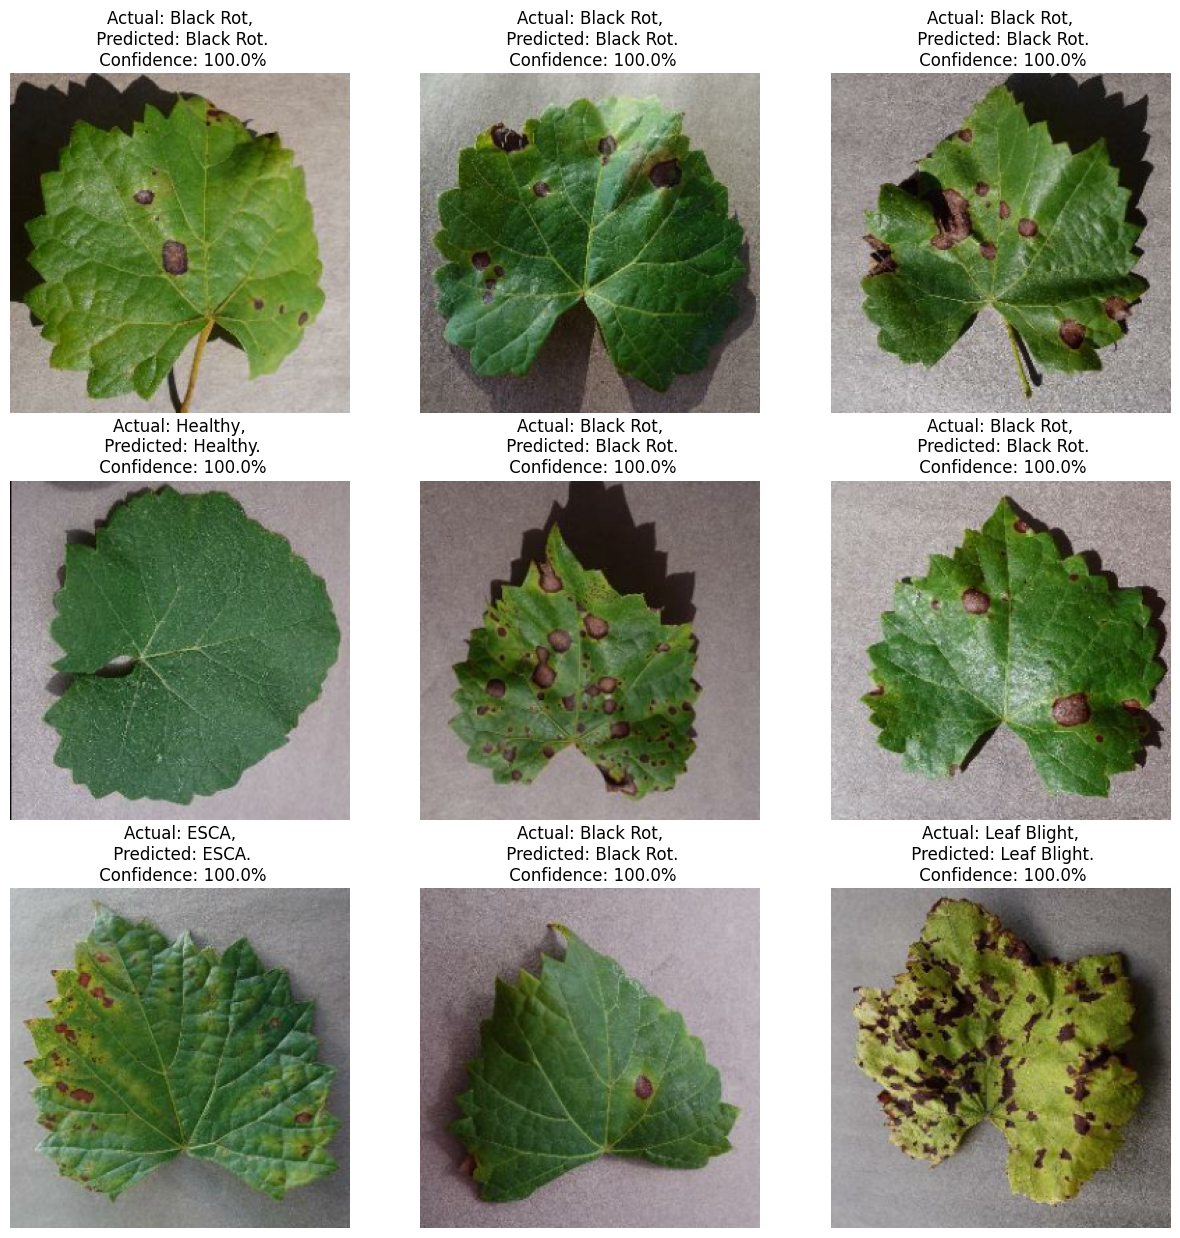

In [15]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array, verbose=0)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

plt.figure(figsize=(15, 15))
for images, labels in testing_ds.take(3):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")
        